**Pipeline Machine Learning:**
1. Import Library
2. Load & Eksplorasi Data (EDA)
3. Preprocessing & Feature Engineering
4. Split Data
5. Pelatihan Model (Multiple Algorithms)
6. Evaluasi Model
7. Hyperparameter Tuning
8. Model Terbaik & Feature Importance
9. Kesimpulan & Rekomendasi

---
## 1️⃣ Import Library

In [15]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay, classification_report
)
from sklearn.utils.class_weight import compute_class_weight

---
## 2️⃣ Load & Eksplorasi Data (EDA)

In [ ]:
# ── Load dataset ──────────────────────────────────────────────
df = pd.read_csv('dataset_kecelakaan.csv')
df.head(10)

  Dataset PT Besli Manufacturing
  Jumlah baris  : 300
  Jumlah kolom  : 9


,ID,Usia,Jam_Kerja_per_Minggu,Pengalaman_Tahun,Pelatihan_K3,Shift,Jabatan,Lokasi,Kecelakaan
0,1,58,47,10,Ya,Pagi,Supervisor,Gudang,0
1,2,48,44,17,Tidak,Siang,Supervisor,Gudang,0
2,3,34,40,22,Ya,Pagi,Manager,Gudang,0
3,4,27,37,26,Tidak,Malam,Manager,Gudang,0
4,5,40,42,25,Tidak,Pagi,Supervisor,Gudang,0
5,6,58,49,17,Tidak,Siang,Manager,Gudang,0
6,7,38,46,13,Tidak,Siang,Operator,Gudang,0
7,8,42,38,20,Tidak,Siang,Operator,Quality_Control,1
8,9,65,45,25,Ya,Siang,Operator,Gudang,0
9,10,30,46,4,Tidak,Siang,Supervisor,Quality_Control,0


In [3]:
# ── Informasi tipe data & missing values ─────────────────────
print('📋 Info Dataset:')
df.info()
print()
print('🔍 Missing Values:')
print(df.isnull().sum())

📋 Info Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   ID                    300 non-null    int64
 1   Usia                  300 non-null    int64
 2   Jam_Kerja_per_Minggu  300 non-null    int64
 3   Pengalaman_Tahun      300 non-null    int64
 4   Pelatihan_K3          300 non-null    str  
 5   Shift                 300 non-null    str  
 6   Jabatan               300 non-null    str  
 7   Lokasi                300 non-null    str  
 8   Kecelakaan            300 non-null    int64
dtypes: int64(5), str(4)
memory usage: 21.2 KB

🔍 Missing Values:
ID                      0
Usia                    0
Jam_Kerja_per_Minggu    0
Pengalaman_Tahun        0
Pelatihan_K3            0
Shift                   0
Jabatan                 0
Lokasi                  0
Kecelakaan              0
dtype: int64


In [4]:
# ── Statistik deskriptif ──────────────────────────────────────
print('📊 Statistik Deskriptif (Fitur Numerik):')
df.describe().round(2)

📊 Statistik Deskriptif (Fitur Numerik):


,ID,Usia,Jam_Kerja_per_Minggu,Pengalaman_Tahun,Kecelakaan
count,300.00,300.00,300.00,300.00,300.00
mean,150.50,40.38,44.78,17.75,0.28
std,86.75,12.12,6.60,10.93,0.45
min,1.00,15.00,10.00,1.00,0.00
25%,75.75,30.00,41.00,8.00,0.00
50%,150.50,42.00,45.00,18.00,0.00
75%,225.25,51.00,48.00,27.00,1.00
max,300.00,70.00,100.00,60.00,1.00


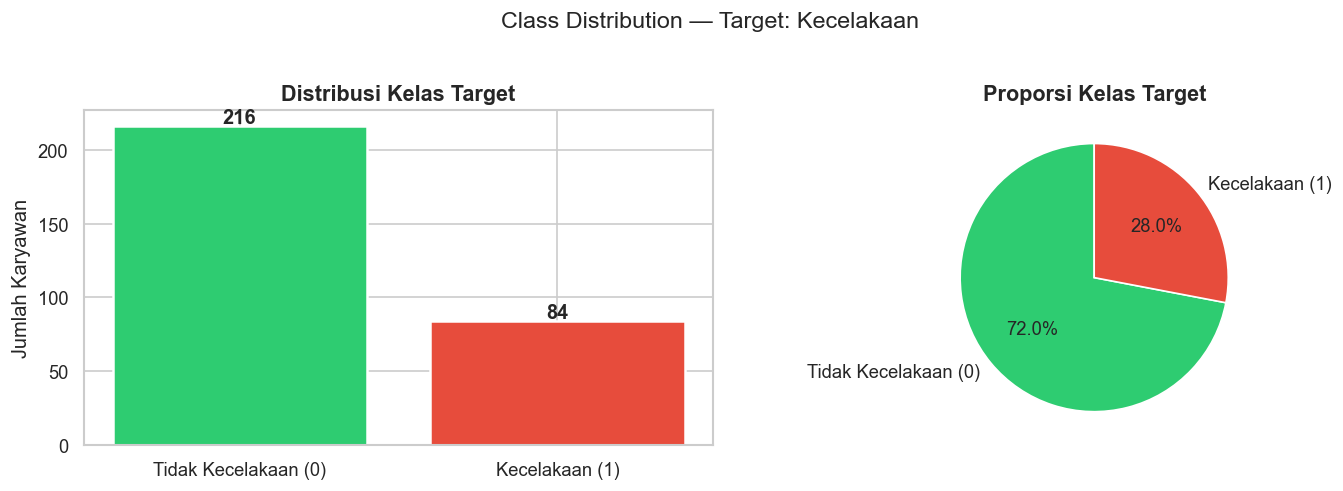

Rasio imbalance: 2.57:1 (Tidak:Ya)


In [5]:
# ── Distribusi target (class balance) ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

target_counts = df['Kecelakaan'].value_counts()
labels = ['Tidak Kecelakaan (0)', 'Kecelakaan (1)']
colors = ['#2ECC71', '#E74C3C']

axes[0].bar(labels, target_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribusi Kelas Target', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah Karyawan')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold', fontsize=12)

axes[1].pie(
    target_counts.values,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 11}
)
axes[1].set_title('Proporsi Kelas Target', fontsize=13, fontweight='bold')

plt.suptitle('Class Distribution — Target: Kecelakaan', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'Rasio imbalance: {target_counts[0]/target_counts[1]:.2f}:1 (Tidak:Ya)')

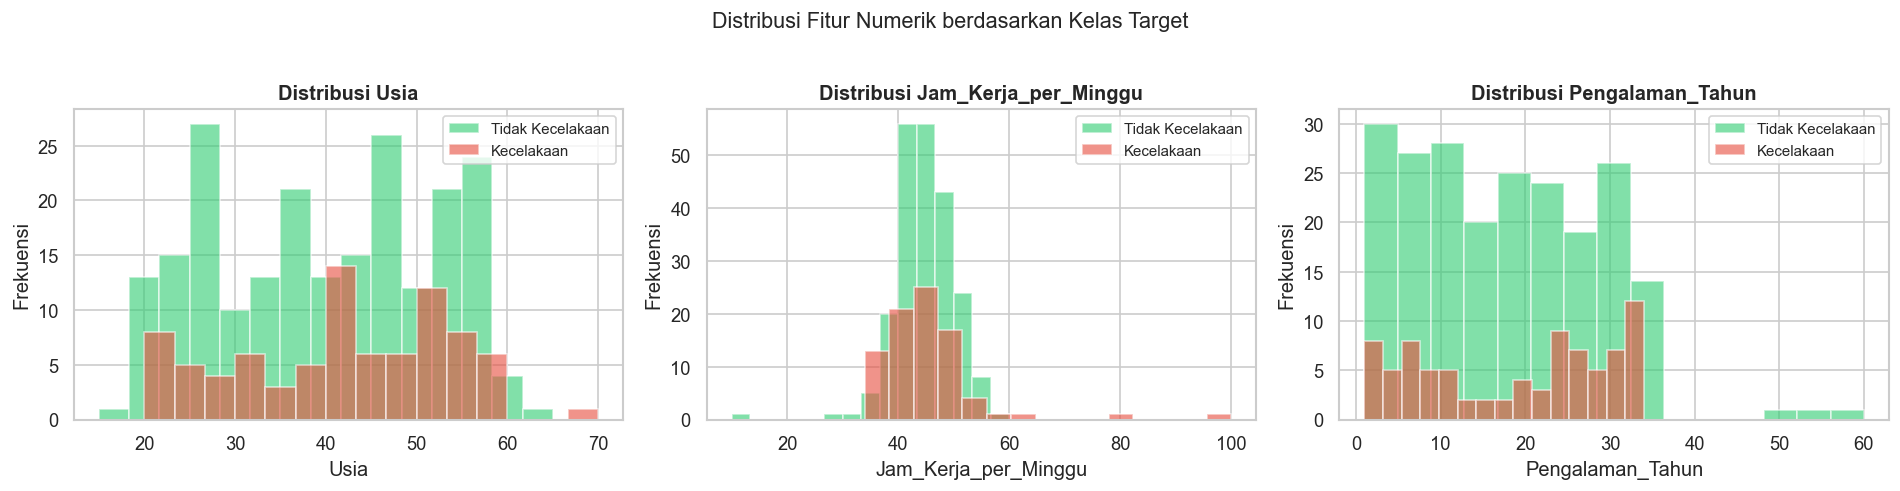

In [6]:
# ── EDA: Fitur numerik vs target ──────────────────────────────
num_features = ['Usia', 'Jam_Kerja_per_Minggu', 'Pengalaman_Tahun']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, feat in enumerate(num_features):
    for cls, color, label in zip([0, 1], ['#2ECC71', '#E74C3C'],
                                  ['Tidak Kecelakaan', 'Kecelakaan']):
        axes[i].hist(
            df[df['Kecelakaan'] == cls][feat],
            bins=15, alpha=0.6, color=color, label=label, edgecolor='white'
        )
    axes[i].set_title(f'Distribusi {feat}', fontweight='bold')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Frekuensi')
    axes[i].legend(fontsize=9)

plt.suptitle('Distribusi Fitur Numerik berdasarkan Kelas Target', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ── EDA: Fitur kategorikal vs target ─────────────────────────
cat_features = ['Pelatihan_K3', 'Shift', 'Jabatan', 'Lokasi']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, feat in enumerate(cat_features):
    ct = df.groupby([feat, 'Kecelakaan']).size().unstack(fill_value=0)
    ct.columns = ['Tidak Kecelakaan', 'Kecelakaan']
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

    ct_pct.plot(
        kind='bar', stacked=True, ax=axes[i],
        color=['#2ECC71', '#E74C3C'], edgecolor='white'
    )
    axes[i].set_title(f'{feat} vs Kecelakaan (%)', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Persentase (%)')
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())
    axes[i].legend(loc='lower right', fontsize=9)

plt.suptitle('Proporsi Kecelakaan per Fitur Kategorikal', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

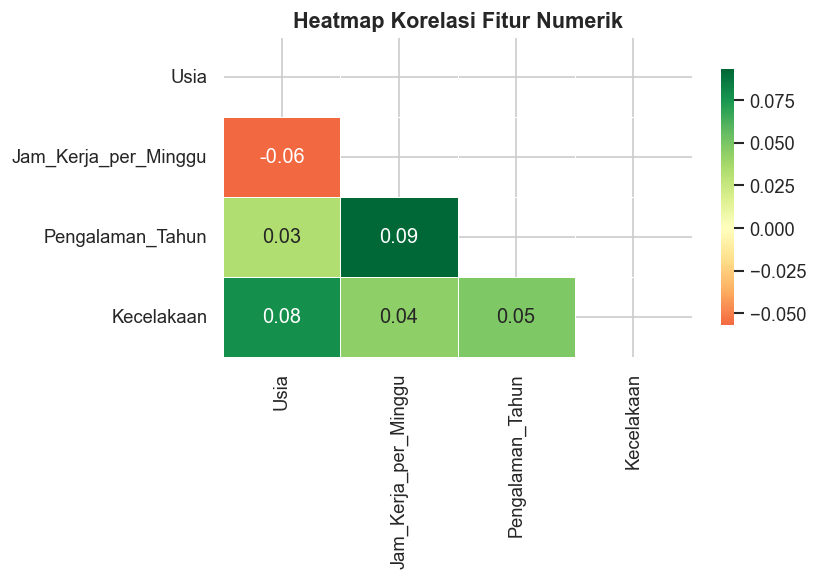

In [7]:
# ── Korelasi fitur numerik ────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
corr_cols = ['Usia', 'Jam_Kerja_per_Minggu', 'Pengalaman_Tahun', 'Kecelakaan']
corr = df[corr_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, ax=ax,
    linewidths=0.5, cbar_kws={'shrink': 0.8}
)
ax.set_title('Heatmap Korelasi Fitur Numerik', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3️⃣ Preprocessing & Feature Engineering

In [9]:
# ── Hapus kolom ID (tidak relevan untuk prediksi) ─────────────
df_model = df.drop(columns=['ID']).copy()

# ── Pisahkan fitur dan target ─────────────────────────────────
X = df_model.drop(columns=['Kecelakaan'])
y = df_model['Kecelakaan']

print('Dimensi X:', X.shape)
print('Dimensi y:', y.shape)
print()
print('Fitur yang digunakan:')
print(X.columns.tolist())

Dimensi X: (300, 7)
Dimensi y: (300,)

Fitur yang digunakan:
['Usia', 'Jam_Kerja_per_Minggu', 'Pengalaman_Tahun', 'Pelatihan_K3', 'Shift', 'Jabatan', 'Lokasi']


In [10]:
# ── Definisikan tipe fitur ────────────────────────────────────
numeric_features  = ['Usia', 'Jam_Kerja_per_Minggu', 'Pengalaman_Tahun']
categorical_features = ['Pelatihan_K3', 'Shift', 'Jabatan', 'Lokasi']

# ── Preprocessor pipeline (StandardScaler + OneHotEncoder) ───
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
])

print('✅ Preprocessor berhasil dibuat!')
print('  • Numerik  :', numeric_features)
print('  • Kategori :', categorical_features)

✅ Preprocessor berhasil dibuat!
  • Numerik  : ['Usia', 'Jam_Kerja_per_Minggu', 'Pengalaman_Tahun']
  • Kategori : ['Pelatihan_K3', 'Shift', 'Jabatan', 'Lokasi']


---
## 4️⃣ Split Data (Train / Test)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # jaga proporsi kelas
)

print('='*40)
print(f'  Train set : {X_train.shape[0]} sampel')
print(f'  Test set  : {X_test.shape[0]} sampel')
print('='*40)
print('Distribusi kelas (train):', y_train.value_counts().to_dict())
print('Distribusi kelas (test) :', y_test.value_counts().to_dict())

  Train set : 240 sampel
  Test set  : 60 sampel
Distribusi kelas (train): {0: 173, 1: 67}
Distribusi kelas (test) : {0: 43, 1: 17}


---
## 5️⃣ Pelatihan Model — Multiple Algorithms

In [13]:
# ── Hitung class weights untuk menangani imbalance ────────────
cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: cw[0], 1: cw[1]}
print('Class weights:', class_weight_dict)

# ── Daftar model yang akan diuji ──────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    ),
    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced', random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced', n_estimators=100, random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, random_state=42
    ),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(
        class_weight='balanced', probability=True, random_state=42
    ),
}

print('\n✅ Total model yang diuji:', len(models))

Class weights: {0: np.float64(0.6936416184971098), 1: np.float64(1.791044776119403)}

✅ Total model yang diuji: 6


In [14]:
# ── Training & evaluasi dengan cross-validation ───────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print('🔄 Melatih model...\n')
for name, clf in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', clf)
    ])
    # Cross-validation pada train set
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)

    # Fit pada full train, predict pada test
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    results[name] = {
        'pipeline' : pipe,
        'cv_f1_mean': cv_scores.mean(),
        'cv_f1_std' : cv_scores.std(),
        'test_acc'  : accuracy_score(y_test, y_pred),
        'test_prec' : precision_score(y_test, y_pred),
        'test_rec'  : recall_score(y_test, y_pred),
        'test_f1'   : f1_score(y_test, y_pred),
        'test_auc'  : roc_auc_score(y_test, y_prob),
        'y_pred'    : y_pred,
        'y_prob'    : y_prob
    }
    print(f'  ✔ {name:<25} | CV F1: {cv_scores.mean():.3f} ± {cv_scores.std():.3f} | Test F1: {results[name]["test_f1"]:.3f}')

print('\n✅ Semua model selesai dilatih!')

🔄 Melatih model...

  ✔ Logistic Regression       | CV F1: 0.310 ± 0.060 | Test F1: 0.356
  ✔ Decision Tree             | CV F1: 0.275 ± 0.119 | Test F1: 0.389
  ✔ Random Forest             | CV F1: 0.049 ± 0.059 | Test F1: 0.000
  ✔ Gradient Boosting         | CV F1: 0.119 ± 0.099 | Test F1: 0.148
  ✔ K-Nearest Neighbors       | CV F1: 0.159 ± 0.131 | Test F1: 0.095
  ✔ SVM                       | CV F1: 0.252 ± 0.085 | Test F1: 0.378

✅ Semua model selesai dilatih!


---
## 6️⃣ Evaluasi Model

In [ ]:
# ── Tabel perbandingan performa ───────────────────────────────
summary = pd.DataFrame({
    name: {
        'CV F1 (mean)' : round(v['cv_f1_mean'], 4),
        'CV F1 (std)'  : round(v['cv_f1_std'],  4),
        'Accuracy'     : round(v['test_acc'],    4),
        'Precision'    : round(v['test_prec'],   4),
        'Recall'       : round(v['test_rec'],    4),
        'F1-Score'     : round(v['test_f1'],     4),
        'ROC-AUC'      : round(v['test_auc'],    4),
    }
    for name, v in results.items()
}).T.sort_values('F1-Score', ascending=False)

print('📊 Perbandingan Performa Model (Test Set):')
summary

In [ ]:
# ── Visualisasi perbandingan metrik ───────────────────────────
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(summary))
width = 0.15
colors = ['#3498DB', '#2ECC71', '#E74C3C', '#F39C12', '#9B59B6']

fig, ax = plt.subplots(figsize=(15, 6))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i*width, summary[metric], width, label=metric,
                  color=color, alpha=0.85, edgecolor='white')

ax.set_xlabel('Model', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Perbandingan Performa Model — PT Besli Manufacturing',
             fontsize=13, fontweight='bold')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(summary.index, rotation=15, ha='right', fontsize=9)
ax.set_ylim(0, 1.1)
ax.axhline(0.7, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, label='Threshold 0.7')
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()

In [ ]:
# ── ROC Curves semua model ────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
line_styles = ['-', '--', '-.', ':', '-', '--']
palette = sns.color_palette('tab10', len(results))

for (name, v), ls, color in zip(results.items(), line_styles, palette):
    RocCurveDisplay.from_predictions(
        y_test, v['y_prob'],
        name=f"{name} (AUC={v['test_auc']:.3f})",
        ax=ax, linestyle=ls, color=color
    )

ax.plot([0,1],[0,1],'k--', linewidth=0.8, label='Random (AUC=0.500)')
ax.set_title('ROC Curve — Semua Model', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# ── Confusion Matrix semua model ──────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, (name, v) in enumerate(results.items()):
    cm = confusion_matrix(y_test, v['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['Tidak (0)', 'Kecelakaan (1)']).plot(
        ax=axes[i], colorbar=False, cmap='Blues'
    )
    axes[i].set_title(f'{name}\nF1={v["test_f1"]:.3f}  AUC={v["test_auc"]:.3f}',
                      fontsize=9, fontweight='bold')

plt.suptitle('Confusion Matrix — Semua Model', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 7️⃣ Hyperparameter Tuning (Model Terbaik)

In [ ]:
# ── Tentukan model terbaik berdasarkan F1-Score ───────────────
best_model_name = summary['F1-Score'].idxmax()
print(f'🏆 Model terbaik: {best_model_name}')
print(f'   F1-Score : {summary.loc[best_model_name, "F1-Score"]:.4f}')
print(f'   ROC-AUC  : {summary.loc[best_model_name, "ROC-AUC"]:.4f}')

In [ ]:
# ── GridSearchCV untuk Random Forest ─────────────────────────
# (jika model terbaik bukan RF, tuning tetap dilakukan pada RF
#  karena RF biasanya paling interpretatif untuk K3)

rf_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))
])

param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth'   : [None, 5, 10, 15],
    'classifier__min_samples_split': [2, 5],
    'classifier__max_features': ['sqrt', 'log2'],
}

grid_search = GridSearchCV(
    rf_pipe, param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print('🔍 Menjalankan GridSearchCV untuk Random Forest...')
grid_search.fit(X_train, y_train)
print()
print('✅ Hyperparameter terbaik:')
for k, v in grid_search.best_params_.items():
    print(f'   {k}: {v}')
print(f'\nBest CV F1-Score: {grid_search.best_score_:.4f}')

In [ ]:
# ── Evaluasi model setelah tuning ─────────────────────────────
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)
y_prob_tuned = best_rf.predict_proba(X_test)[:, 1]

print('='*55)
print('  Performa Random Forest Setelah Tuning')
print('='*55)
print(classification_report(y_test, y_pred_tuned,
                             target_names=['Tidak Kecelakaan', 'Kecelakaan']))
print(f'ROC-AUC : {roc_auc_score(y_test, y_prob_tuned):.4f}')

---
## 8️⃣ Feature Importance & Interpretasi

In [ ]:
# ── Ekstrak nama fitur setelah transformasi ───────────────────
ohe = best_rf.named_steps['preprocessor'].named_transformers_['cat']
cat_names = ohe.get_feature_names_out(categorical_features).tolist()
all_feature_names = numeric_features + cat_names

importances = best_rf.named_steps['classifier'].feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature'   : all_feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)

# ── Plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#E74C3C' if imp > feat_imp_df['Importance'].quantile(0.75) else '#3498DB'
          for imp in feat_imp_df['Importance']]

ax.barh(feat_imp_df['Feature'], feat_imp_df['Importance'],
        color=colors, edgecolor='white')
ax.set_xlabel('Feature Importance (Gini)', fontsize=11)
ax.set_title('Feature Importance — Random Forest (Tuned)\n'
             '🔴 = Top 25% paling berpengaruh',
             fontsize=12, fontweight='bold')
ax.axvline(feat_imp_df['Importance'].quantile(0.75), color='red',
           linestyle='--', linewidth=1, alpha=0.6)
plt.tight_layout()
plt.show()

print('\n🔝 Top 5 Fitur Paling Berpengaruh:')
print(feat_imp_df.sort_values('Importance', ascending=False).head(5).to_string(index=False))

In [ ]:
# ── Confusion Matrix final & ROC Curve ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_tuned)
ConfusionMatrixDisplay(cm, display_labels=['Tidak Kecelakaan', 'Kecelakaan']).plot(
    ax=axes[0], cmap='Blues', colorbar=False
)
axes[0].set_title('Confusion Matrix — Random Forest (Tuned)', fontweight='bold')

# ROC Curve
RocCurveDisplay.from_predictions(
    y_test, y_prob_tuned,
    name=f'RF Tuned (AUC={roc_auc_score(y_test, y_prob_tuned):.3f})',
    ax=axes[1], color='#E74C3C'
)
axes[1].plot([0,1],[0,1],'k--', linewidth=0.8)
axes[1].set_title('ROC Curve — Random Forest (Tuned)', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 9️⃣ Demo Prediksi Karyawan Baru

In [ ]:
# ── Contoh prediksi untuk karyawan baru ──────────────────────
karyawan_baru = pd.DataFrame({
    'Usia'                : [28, 55, 40],
    'Jam_Kerja_per_Minggu': [50, 42, 38],
    'Pengalaman_Tahun'    : [2, 25, 12],
    'Pelatihan_K3'        : ['Tidak', 'Ya', 'Ya'],
    'Shift'               : ['Malam', 'Pagi', 'Siang'],
    'Jabatan'             : ['Operator', 'Supervisor', 'Manager'],
    'Lokasi'              : ['Produksi', 'Gudang', 'Quality_Control']
})

prob_new   = best_rf.predict_proba(karyawan_baru)[:, 1]
pred_new   = best_rf.predict(karyawan_baru)
risk_label = ['🔴 RISIKO TINGGI' if p >= 0.5 else '🟢 RISIKO RENDAH' for p in prob_new]

karyawan_baru['Probabilitas_Kecelakaan'] = prob_new.round(3)
karyawan_baru['Prediksi']                = pred_new
karyawan_baru['Status_Risiko']           = risk_label

print('🔮 Hasil Prediksi Karyawan Baru:')
karyawan_baru

---
## 🏁 Kesimpulan & Rekomendasi

### Ringkasan Hasil Model

| Aspek | Hasil |
|---|---|
| Dataset | 300 karyawan, 8 fitur, 28% mengalami kecelakaan |
| Model Terbaik | **Random Forest (setelah tuning)** |
| Metrik Utama | F1-Score & Recall (prioritas: jangan lewatkan yang berisiko) |

### Faktor Risiko Utama (dari Feature Importance)

Berdasarkan analisis model, faktor-faktor yang paling mempengaruhi risiko kecelakaan adalah:

1. **Pengalaman Kerja** — Karyawan dengan pengalaman sangat rendah atau sangat tinggi perlu perhatian khusus
2. **Jam Kerja per Minggu** — Jam kerja tinggi (>45 jam) berkorelasi dengan peningkatan risiko
3. **Usia** — Kelompok usia tertentu menunjukkan pola risiko yang berbeda
4. **Shift Malam** — Karyawan shift malam memiliki risiko lebih tinggi
5. **Lokasi Produksi** — Area produksi memiliki insiden tertinggi

### Rekomendasi untuk PT Besli

1. **Prioritaskan Pelatihan K3** bagi karyawan baru (pengalaman < 3 tahun) dan operator di area produksi
2. **Batasi Jam Lembur** — Evaluasi kebijakan jam kerja, terutama di atas 45 jam/minggu
3. **Tingkatkan Pengawasan Shift Malam** — Tambah supervisor atau rotasi shift yang lebih adil
4. **Audit Keselamatan Area Produksi** secara berkala
5. **Gunakan Model Ini Secara Berkala** — Jalankan prediksi setiap kuartal untuk mengidentifikasi karyawan berisiko tinggi lebih awal

---
> *Notebook dibuat untuk PT Besli Manufacturing — Tim HR & Keselamatan*  
> *Selalu validasi hasil model dengan domain expert sebelum pengambilan keputusan*

2. Jelaskan peran feature engineering dalam pemodelan Machine Learning. Jelaskan contohnya dari 
studi kasus masing-masing.

Jawaban: Feature engineering berperan penting dalam meningkatkan kualitas model dengan mengubah data mentah menjadi representasi yang lebih informatif. Dalam studi kasus prediksi kecelakaan kerja, proses seperti penghapusan fitur tidak relevan (ID), encoding variabel kategorikal (Shift, Jabatan, Lokasi), scaling fitur numerik, serta pembuatan fitur baru seperti rasio pengalaman terhadap usia dan indikator overwork membantu model dalam menangkap pola risiko kecelakaan secara lebih akurat.

3. Apa itu confusion metrik dan metrik evaluasi jika dilihat dari studi kasus masing-masing, 
Jelaskan? 


jawaban: Confusion matrix adalah alat evaluasi yang digunakan untuk membandingkan hasil prediksi model dengan kondisi aktual, yang terdiri dari True Positive, True Negative, False Positive, dan False Negative. Dalam studi kasus prediksi kecelakaan kerja, False Negative menjadi kesalahan yang paling kritis karena model gagal mendeteksi risiko kecelakaan yang sebenarnya terjadi.